# RSDA
Rotational Spring Damper Actuator
- 회전 각도와 각속도에 따라 토크를 만들어내는 링크

https://github.com/projectchrono/chrono/blob/main/src/demos/python/mbs/demo_MBS_rot_spring.py

### 1. 정의
ChLinkRSDA는 두 물체 사이의 **상대 회전각에 따라 토크를 생성하는 1차원 회전 스프링-댐퍼 요소**이다.

즉, 특정 축을 중심으로 회전하는 시스템에서  
각도 변화에 따라 복원 토크를 발생시킨다.
### 2. 물리적 의미
RSDA는 다음 3가지 요소를 포함한다. 

- Rotational Spring (비틀림 탄성력)
- Rotational Damper (회전 감쇠)
- Actuator (외부 토크 입력 가능)

 ** TSDA가 "거리 기반 힘"이라면  
 ** RSDA는 "각도 기반 토크"이다

 ### 3. 기본 토크 모델
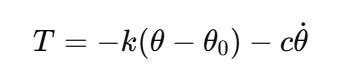

- θ: 현재 회전각
- θ_0: 자연각(rest angle) <- 기준 각도
- k: 회전 스프링 상수
- c: 회전 감쇠 계수
- θ': 각속도

즉, 물체가 기준 각도에서 벗어나면 다시 돌아가려는 토크가 생기고,  
회전 속도가 크면 감쇠 토크가 추가되어 진동이 점차 줄어들게 된다.


### TSDA vs RSDA

| 항목  | TSDA                     | RSDA                                    |
| --- | ------------------------ | --------------------------------------- |
| 기준  | 거리                       | 각도                                      |
| 물리량 | 힘 (Force)                | 토크 (Torque)                             |
| 변수  | 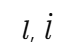         | 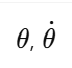                |
| 식   | 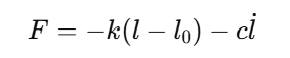 | 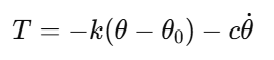 |


### 4. 작동 방식 (내부 흐름)
1. 두 물체 사이의 회전축 정의  
2. 상대 회전각 θ 계산  
3. 상대 각속도 θ' 계산  
4. 토크 T 계산  
5. 두 물체에 반대 방향 토크 적용  
6. solver가 전체 동역학 계산  

### 5. 구현 방식
#### (1) 기본 모델 (선형 스프링-댐퍼)
내부적으로 위 토크 식을 자동 적용

#### (2) 사용자 정의 토크
```python
spring.RegisterTorqueFunctor(MySpringTorque())

### 6. 특징
- 1D 회전 자유도에 작용하는 토크 요소
- Revolute joint와 함께 사용되는 경우가 많음
- 에너지 저장 (회전 탄성 에너지)
- 감쇠로 에너지 소산
- 사용자 정의 토크 함수 지원

# Tutorial: demo_MBS_rot_spring.py

### 원본 깃허브 코드

In [1]:
# =============================================================================
# PROJECT CHRONO - http://projectchrono.org
#
# Copyright (c) 2014 projectchrono.org
# All rights reserved.
#
# Use of this source code is governed by a BSD-style license that can be found
# in the LICENSE file at the top level of the distribution and at
# http://projectchrono.org/license-chrono.txt.
#
# =============================================================================
# Authors: Radu Serban
# =============================================================================
#
# Simple example demonstrating the use of ChLinkRSDA.
#
# Recall that Irrlicht uses a left-hand frame, so everything is rendered with
# left and right flipped.
#
# =============================================================================

import pychrono as chrono
import pychrono.irrlicht as irr
import math as m

# =============================================================================

spring_coef = 40
damping_coef = 2
rest_angle = m.pi / 6

# =============================================================================

# Functor class implementing the torque for a ChLinkRSDA link.
class MySpringTorque(chrono.TorqueFunctor):
    def __init__(self):
        super(MySpringTorque, self).__init__()
    
    def evaluate(self,    #
                 time,    # current time
                 rangle,  # rest angle
                 angle,   # relative angle of rotation
                 vel,     # relative angular speed
                 link):   # associated link                       
        torque = -spring_coef * (angle - rest_angle) - damping_coef * vel
        return torque

# =============================================================================

print("Copyright (c) 2017 projectchrono.org")

sys = chrono.ChSystemNSC()
sys.SetGravitationalAcceleration(chrono.ChVector3d(0, 0, 0))

# Revolute joint frame 
rev_rot = chrono.QuatFromAngleX(m.pi / 6.0)
rev_dir = rev_rot.GetAxisZ()
rev_pos = chrono.ChVector3d(+1, 0, 0)

# Create ground body
ground = chrono.ChBody()
sys.AddBody(ground)
ground.SetFixed(True)
ground.EnableCollision(False)

# Visualization for revolute joint
seg = chrono.ChLineSegment(rev_pos + rev_dir * 0.2, rev_pos - rev_dir * 0.2)
cyl_rev = chrono.ChVisualShapeCylinder(0.1, seg.GetLength())
ground.AddVisualShape(cyl_rev, seg.GetFrame())

# Offset from joint to body COM
offset = chrono.ChVector3d(1.5, 0, 0)

# Consistent initial velocities
omega = 5.0
ang_vel = rev_dir * omega
lin_vel = ang_vel % offset

# Create pendulum body
body = chrono.ChBody()
sys.AddBody(body)
body.SetPos(rev_pos + offset)
body.SetPosDt(lin_vel)
body.SetAngVelParent(ang_vel)
body.SetFixed(False)
body.EnableCollision(False)
body.SetMass(1)
body.SetInertiaXX(chrono.ChVector3d(1, 1, 1))

# Attach visualization assets
sph = chrono.ChVisualShapeSphere(0.3)
body.AddVisualShape(sph)
cyl = chrono.ChVisualShapeCylinder(0.1, 1.5)
cyl.SetColor(chrono.ChColor(0.7, 0.8, 0.8))
body.AddVisualShape(cyl, chrono.ChFramed(chrono.ChVector3d(-0.75,0,0), chrono.QuatFromAngleY(chrono.CH_PI_2)))

# Create revolute joint between body and ground
rev = chrono.ChLinkLockRevolute()
rev.Initialize(body, ground, chrono.ChFramed(rev_pos, rev_rot))
sys.AddLink(rev)

# Create the rotational spring between body and ground
torque = MySpringTorque()
spring = chrono.ChLinkRSDA()
spring.Initialize(body, ground, chrono.ChFramed(rev_pos, rev_rot))
spring.RegisterTorqueFunctor(torque)
rsda = chrono.ChVisualShapeRotSpring(0.5, 40)
rsda.SetColor(chrono.ChColor(0, 0, 0))
spring.AddVisualShape(rsda)
sys.AddLink(spring)

# Create the Irrlicht visualization
vis = irr.ChVisualSystemIrrlicht()
vis.AttachSystem(sys)
vis.SetWindowSize(1024,768)
vis.SetWindowTitle('ChLinkRSDA demo')
vis.Initialize()
vis.AddLogo(chrono.GetChronoDataFile('logo_chrono_alpha.png'))
vis.AddSkyBox()
vis.AddCamera(chrono.ChVector3d(3, 1, 3))
vis.AddTypicalLights()

# Simulation loop
frame = 0
while vis.Run():
    vis.BeginScene() 
    vis.Render()
    irr.drawAllCOGs(vis, 1.0)
    irr.drawAllLinkframes(vis, 1.5)
    vis.EndScene()
    sys.DoStepDynamics(1e-3)

    if (frame % 50 == 0) :
        print('{:.6}'.format(str(sys.GetChTime())))
        print('Body position      ', body.GetPos())
        print('Body lin. vel      ', body.GetPosDt())
        print('Body abs. ang. vel ', body.GetAngVelParent())
        print('Body loc. ang. vel ', body.GetAngVelLocal())
        print('Rot. spring-damper ', spring.GetAngle(), '  ', spring.GetTorque())
        print('---------------')


    frame += 1


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\lahee\anaconda3\envs\chrono\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\lahee\anaconda3\envs\chrono\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\lahee\anaconda3\envs\chrono\Lib\site-packages\ipykernel\kernelapp.py", line 758, in start
    self.io_loop.start()
  File "c:

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Copyright (c) 2017 projectchrono.org
0.001
Body position       [ 2.5, 0.00648282, 0.00374286 ]
Body lin. vel       [ 0, 6.48282, 3.74286 ]
Body abs. ang. vel  [ 1.73472e-18, -2.49524, 4.32188 ]
Body loc. ang. vel  [ 0, -2.49524, 4.32188 ]
Rot. spring-damper  -0.004990478784300331    31.12452774390463
---------------
0.0510
Body position       [ 2.4566, 0.310285, 0.179143 ]
Body lin. vel       [ -1.57891, 5.61249, 3.24037 ]
Body abs. ang. vel  [ -5.55112e-17, -2.22342, 3.85107 ]
Body loc. ang. vel  [ 5.55112e-17, -2.22342, 3.85107 ]
Rot. spring-damper  -0.24118648662375422    39.48507501535635
---------------
0.1010
Body position       [ 2.35256, 0.56165, 0.324269 ]
Body lin. vel       [ -2.44528, 4.43791, 2.56223 ]
Body abs. ang. vel  [ -1.59317e-13, -1.89265, 3.27816 ]
Body loc. ang. vel  [ -1.65423e-13, -1.89265, 3.27816 ]
Rot. spring-damper  -0.4471030656415548    46.398662999749504
---------------
0.1510
Body position       [ 2.22306, 0.752073, 0.43421 ]
Body lin. vel       [ -2.62

## 코드 분석


### 1. 코드 개요

이 코드는 하나의 강체(body)를 고정된 ground에 **revolute joint**로 연결하여
특정 축을 중심으로 회전할 수 있게 만든 뒤,
같은 축에 **ChLinkRSDA**를 추가해서
회전 스프링-댐퍼 토크를 작용시키는 예제임

즉, 선형 스프링(TSDA)이 아니라
**비틀림 스프링(torsional spring)** 을 구현한 코드임

#### 코드의 목적
- 회전축을 가진 body를 만들고
- revolute joint로 자유도 1개를 정의하고
- RSDA로 그 자유도에 회전 토크를 부여하는
회전 동역학 모델링 예제


### 2. 전체 구조

코드 흐름은 다음과 같다.

1. 회전 스프링 파라미터 정의
2. 사용자 정의 토크 함수 `MySpringTorque` 작성
3. 물리 시스템 생성
4. 회전축 위치와 방향 정의
5. ground 생성
6. 회전하는 body 생성
7. revolute joint 생성
8. RSDA 생성 및 토크 함수 등록
9. Irrlicht 시각화
10. 시뮬레이션 루프에서 시간 전진 및 상태 출력


### 3. 파라미터 부분


In [2]:
import pychrono as chrono
import pychrono.irrlicht as irr
import math as m

In [4]:
spring_coef = 40        # 회전 스프링 강성 k
damping_coef = 2        # 회전 감쇠 계수 c
rest_angle = m.pi / 6   # 기준 각도 (30도) -> 이 각도로 돌아가려는 힘 발생

### 4. 사용자 정의 토크 함수
이 클래스는 RSDA가 사용할 트크 계산식을 직접 정의한다.

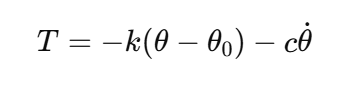

- `angle` : 현재 상대 회전각
- `vel` : 상대 각속도
- `rest_angle` : 기준 각도

즉, 
- 각도가 기준보다 크면 원래 각도로 돌아가려는 토크 발생
- 각속도가 크면 회전을 줄이려는 감쇠 토크 발생


In [5]:
class MySpringTorque(chrono.TorqueFunctor):
    def __init__(self):
        super(MySpringTorque, self).__init__()

    # 매 timestep마다 호출됨 (토크 계산)
    def evaluate(self, time, rangle, angle, vel, link):
        # T = -k(θ - θ0) - cθ_dot
        torque = -spring_coef * (angle - rest_angle) - damping_coef * vel
        return torque


### 5. 시스템 생성
- ChSystemNSC() : 전체 물리 시스템 생성
- 중력 0 설정 : 중력 효과 없이 회전 스프링-댐퍼만 확인하기 위해

즉 이 예제는 진자 운동 자체보다는
회전 스프링 토크의 효과를 보기 위한 코드임

In [6]:
sys = chrono.ChSystemNSC()
sys.SetGravitationalAcceleration(chrono.ChVector3d(0, 0, 0)) # 중력 제거 → 순수 회전 스프링 효과만 보기 위함

### 6. 회전축 설정
이 부분은 회전축의 위치와 방향을 결정

- `rev_pos` : 조인트가 위치할 점
- `rev_rot` : 조인트 좌표계의 회전
- `rev_dir` : 실제 회전축 방향 벡터

즉, "어디에 어떤 방향의 힌지를 둘 것인가"를 정함

In [7]:
rev_rot = chrono.QuatFromAngleX(m.pi / 6.0)  # 회전축 방향 정의
rev_dir = rev_rot.GetAxisZ()                 # 실제 회전축 벡터
rev_pos = chrono.ChVector3d(+1, 0, 0)        # 회전축 위치

### 7. ground 생성
ground는 고정된 기준 물체

- 움직이지 않음
- 충돌 계산 안 함

여기에 revolute joint와 RSDA가 연결된다.

In [8]:
ground = chrono.ChBody()
sys.AddBody(ground)

ground.SetFixed(True)          # 완전히 고정
ground.EnableCollision(False)  # 충돌 계산 안 함

### 8. 회전축 시각화
이 부분은 회전축 자체를 화면에 보이게 만드는 시각화 코드

물리 계산에는 직접 영향 없고,
“여기가 힌지 축이다”를 원통으로 표시하는 역할

In [9]:
seg = chrono.ChLineSegment(
    rev_pos + rev_dir * 0.2,
    rev_pos - rev_dir * 0.2
)

cyl_rev = chrono.ChVisualShapeCylinder(0.1, seg.GetLength())
ground.AddVisualShape(cyl_rev, seg.GetFrame())  # 회전축을 원통으로 표시

### 9. body와 회전 운동 초기조건
`offset`

회전축에서 body의 질량중심(COM)까지 거리다.
즉 막대 길이 같은 의미다.


`omega`

초기 각속도 크기


`ang_vel`

회전축 방향을 따라 주어진 초기 각속도 벡터


`lin_vel = ang_vel % offset`

질량중심이 회전하려면 각속도만 있는 게 아니라
그에 맞는 선속도도 가져야 한다.

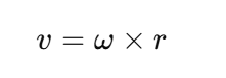

를 계산한 식


In [11]:
offset = chrono.ChVector3d(1.5, 0, 0)  # 회전축에서 COM까지 거리

# 초기 회전 속도 설정
omega = 5.0
ang_vel = rev_dir * omega              # 각속도 벡터
lin_vel = ang_vel % offset             # v = ω × r (외적)


### 10. body 생성
이 body가 실제로 회전하는 물체

- 위치: 회전축에서 `offset`만큼 떨어진 위치
- 선속도: `lin_vel`
- 각속도: `ang_vel`
- 질량: 1
- 관성모멘트: (1,1,1)

즉 처음부터 회전 운동을 하도록 초기조건을 준 것

In [12]:
body = chrono.ChBody()
sys.AddBody(body)

# 위치 = 회전축 + offset
body.SetPos(rev_pos + offset)

# 초기 선속도 / 각속도
body.SetPosDt(lin_vel)
body.SetAngVelParent(ang_vel)

body.SetFixed(False)
body.EnableCollision(False)

body.SetMass(1)  # 질량
body.SetInertiaXX(chrono.ChVector3d(1, 1, 1))  # 관성모멘트

### 11. body 시각화
- 구체: 질량중심 부근 표시
- 원통: 막대처럼 보이게 함

즉 body를 진자처럼 보이게 하는 시각화용 요소


In [13]:
# 질량 중심 표시용 구
sph = chrono.ChVisualShapeSphere(0.3)
body.AddVisualShape(sph)

# 막대처럼 보이게 하는 원통
cyl = chrono.ChVisualShapeCylinder(0.1, 1.5)
cyl.SetColor(chrono.ChColor(0.7, 0.8, 0.8))

body.AddVisualShape(
    cyl,
    chrono.ChFramed(
        chrono.ChVector3d(-0.75, 0, 0),
        chrono.QuatFromAngleY(chrono.CH_PI_2)
    )
)

### 12. Revolute joint 생성 ***(중요)

`ChLinkLockRevolute()`는 body와 ground를 연결하여
한 축을 중심으로만 회전 가능하게 만든다.

즉 역할은:

- body를 ground에 고정
- 하지만 특정 축 회전은 허용


RSDA는 이 조인트 없이 단독으로 쓰는 것이 아니라,
보통 이런 회전 조인트와 함께 사용된다.

In [15]:
rev = chrono.ChLinkLockRevolute()

# body와 ground를 회전축 기준으로 연결
rev.Initialize(body, ground, chrono.ChFramed(rev_pos, rev_rot))

sys.AddLink(rev)


### 13. RSDA 생성 ***

- `MySpringTorque()` : 직접 만든 토크 식
- `ChLinkRSDA()` : 회전 스프링-댐퍼 생성
- `Initialize(...)` : body와 ground를 같은 축으로 연결
- `RegisterTorqueFunctor(torque)` : 사용자 정의 토크 함수 등록

즉 매 timestep마다 RSDA는
현재 상대 회전각과 각속도를 계산한 뒤
`MySpringTorque.evaluate()`를 호출하여 토크를 계산한다.

In [16]:
torque = MySpringTorque()   # 우리가 만든 토크 함수

spring = chrono.ChLinkRSDA()

# 같은 회전축에 연결
spring.Initialize(body, ground, chrono.ChFramed(rev_pos, rev_rot))

# 토크 함수 등록 → 매 timestep마다 호출됨
spring.RegisterTorqueFunctor(torque)


### 14. RSDA 시각화
회전 스프링 모양을 보여주는 시각화 코드

TSDA의 ChVisualShapeSpring이 직선 스프링 모양이었다면,
이건 회전 스프링 모양이다.

In [17]:
rsda = chrono.ChVisualShapeRotSpring(0.5, 40)
rsda.SetColor(chrono.ChColor(0, 0, 0))

spring.AddVisualShape(rsda)

sys.AddLink(spring)

### 15. 시각화 시스템
화면 출력용 설정

- 시스템 연결
- 창 생성
- 카메라/빛 추가

물리 계산 핵심은 아니고, 결과를 보기 위한 설정임

In [ ]:
vis = irr.ChVisualSystemIrrlicht()

vis.AttachSystem(sys)

vis.SetWindowSize(1024, 768)
vis.SetWindowTitle('RSDA demo')

vis.Initialize()

vis.AddLogo(chrono.GetChronoDataFile('logo_chrono_alpha.png'))
vis.AddSkyBox()

vis.AddCamera(chrono.ChVector3d(3, 1, 3))
vis.AddTypicalLights()

: 

### 16. 시뮬레이션 루프
매 프레임마다 하는 일은:

1. 현재 상태 렌더링
2. 질량중심(COG) 표시
3. 링크 프레임 표시시간 0.001초 전진
4. 시간 0.001초 전진

이중 핵심은: `sys.DoStepDynamics(1e-3)`

이 순간 Chrono가

- 상대 회전각 계산
- 상대 각속도 계산
- RSDA 토크 계산
- 운동방정식 풀이
- 새로운 위치/속도 갱신

을 수행함

In [ ]:
frame = 0

while vis.Run():

    vis.BeginScene()
    vis.Render()

    # 질량 중심 / 링크 좌표계 표시
    irr.drawAllCOGs(vis, 1.0)
    irr.drawAllLinkframes(vis, 1.5)

    vis.EndScene()

    # 물리 계산 1 step 진행
    sys.DoStepDynamics(1e-3)


### 17. 출력 부분
50프레임마다 상태를 출력

주요 출력값 의미
- `body.GetPos()`: body의 현재 위치
- `body.GetPosDt()`: body의 선속도
- `body.GetAngVelParent()`: 전역 좌표계 기준 각속도
- `body.GetAngVelLocal()`: body 로컬 좌표계 기준 각속도
- `spring.GetAngle()`: RSDA의 현재 상대 회전각
- `spring.GetTorque()`: 현재 RSDA가 발생시키는 토크

즉 마지막 줄이 가장 중요함

-> 현재 각도와 그에 따른 복원/감쇠 토크를 직접 확인할 수 있다.

In [ ]:
    if (frame % 50 == 0):

        print('Time:', sys.GetChTime())

        print('Body position      ', body.GetPos())
        print('Body lin. vel      ', body.GetPosDt())
        print('Body abs. ang. vel ', body.GetAngVelParent())
        print('Body loc. ang. vel ', body.GetAngVelLocal())

        # RSDA 핵심 출력
        print('Rot. spring angle  ', spring.GetAngle())   # 현재 회전각
        print('Rot. spring torque ', spring.GetTorque())  # 현재 토크

        print('---------------')

    frame += 1

=========================================================================================
## 전체 코드 (실행용)

In [1]:
# =============================================================================
# PROJECT CHRONO - 회전 스프링-댐퍼(RSDA) 예제
# =============================================================================

import pychrono as chrono
import pychrono.irrlicht as irr
import math as m

# =============================================================================
# [1] 스프링 파라미터 설정
# =============================================================================

spring_coef = 40        # 회전 스프링 강성 k
damping_coef = 2        # 회전 감쇠 계수 c
rest_angle = m.pi / 6   # 기준 각도 (30도) -> 이 각도로 돌아가려는 힘 발생

# =============================================================================
# [2] 사용자 정의 토크 함수 (RSDA 핵심)
# =============================================================================

class MySpringTorque(chrono.TorqueFunctor):
    def __init__(self):
        super(MySpringTorque, self).__init__()

    # 매 timestep마다 호출됨 (토크 계산)
    def evaluate(self, time, rangle, angle, vel, link):
        # T = -k(θ - θ0) - cθ_dot
        torque = -spring_coef * (angle - rest_angle) - damping_coef * vel
        return torque


# =============================================================================
# [3] 시스템 생성
# =============================================================================

print("RSDA demo start")

sys = chrono.ChSystemNSC()

# 중력 제거 → 순수 회전 스프링 효과만 보기 위함
sys.SetGravitationalAcceleration(chrono.ChVector3d(0, 0, 0))


# =============================================================================
# [4] 회전축(힌지) 설정
# =============================================================================

rev_rot = chrono.QuatFromAngleX(m.pi / 6.0)  # 회전축 방향 정의
rev_dir = rev_rot.GetAxisZ()                 # 실제 회전축 벡터
rev_pos = chrono.ChVector3d(+1, 0, 0)        # 회전축 위치


# =============================================================================
# [5] ground (고정 물체) 생성
# =============================================================================

ground = chrono.ChBody()
sys.AddBody(ground)

ground.SetFixed(True)          # 완전히 고정
ground.EnableCollision(False)  # 충돌 계산 안 함


# =============================================================================
# [6] 회전축 시각화 (단순 표시용)
# =============================================================================

seg = chrono.ChLineSegment(
    rev_pos + rev_dir * 0.2,
    rev_pos - rev_dir * 0.2
)

cyl_rev = chrono.ChVisualShapeCylinder(0.1, seg.GetLength())
ground.AddVisualShape(cyl_rev, seg.GetFrame())  # 회전축을 원통으로 표시


# =============================================================================
# [7] 회전하는 body 생성
# =============================================================================

offset = chrono.ChVector3d(1.5, 0, 0)  # 회전축에서 COM까지 거리

# 초기 회전 속도 설정
omega = 5.0
ang_vel = rev_dir * omega              # 각속도 벡터
lin_vel = ang_vel % offset             # v = ω × r (외적)


body = chrono.ChBody()
sys.AddBody(body)

# 위치 = 회전축 + offset
body.SetPos(rev_pos + offset)

# 초기 선속도 / 각속도
body.SetPosDt(lin_vel)
body.SetAngVelParent(ang_vel)

body.SetFixed(False)
body.EnableCollision(False)

body.SetMass(1)  # 질량
body.SetInertiaXX(chrono.ChVector3d(1, 1, 1))  # 관성모멘트


# =============================================================================
# [8] body 시각화 (보기 좋게)
# =============================================================================

# 질량 중심 표시용 구
sph = chrono.ChVisualShapeSphere(0.3)
body.AddVisualShape(sph)

# 막대처럼 보이게 하는 원통
cyl = chrono.ChVisualShapeCylinder(0.1, 1.5)
cyl.SetColor(chrono.ChColor(0.7, 0.8, 0.8))

body.AddVisualShape(
    cyl,
    chrono.ChFramed(
        chrono.ChVector3d(-0.75, 0, 0),
        chrono.QuatFromAngleY(chrono.CH_PI_2)
    )
)


# =============================================================================
# [9] Revolute joint (힌지) 생성
# =============================================================================

rev = chrono.ChLinkLockRevolute()

# body와 ground를 회전축 기준으로 연결
rev.Initialize(body, ground, chrono.ChFramed(rev_pos, rev_rot))

sys.AddLink(rev)


# =============================================================================
# [10] RSDA (회전 스프링-댐퍼) 생성
# =============================================================================

torque = MySpringTorque()   # 우리가 만든 토크 함수

spring = chrono.ChLinkRSDA()

# 같은 회전축에 연결
spring.Initialize(body, ground, chrono.ChFramed(rev_pos, rev_rot))

# 토크 함수 등록 → 매 timestep마다 호출됨
spring.RegisterTorqueFunctor(torque)


# =============================================================================
# [11] RSDA 시각화 (스프링 모양)
# =============================================================================

rsda = chrono.ChVisualShapeRotSpring(0.5, 40)
rsda.SetColor(chrono.ChColor(0, 0, 0))

spring.AddVisualShape(rsda)

sys.AddLink(spring)


# =============================================================================
# [12] Irrlicht 시각화 설정
# =============================================================================

vis = irr.ChVisualSystemIrrlicht()

vis.AttachSystem(sys)

vis.SetWindowSize(1024, 768)
vis.SetWindowTitle('RSDA demo')

vis.Initialize()

vis.AddLogo(chrono.GetChronoDataFile('logo_chrono_alpha.png'))
vis.AddSkyBox()

vis.AddCamera(chrono.ChVector3d(3, 1, 3))
vis.AddTypicalLights()


# =============================================================================
# [13] 시뮬레이션 루프
# =============================================================================

frame = 0

while vis.Run():

    vis.BeginScene()
    vis.Render()

    # 질량 중심 / 링크 좌표계 표시
    irr.drawAllCOGs(vis, 1.0)
    irr.drawAllLinkframes(vis, 1.5)

    vis.EndScene()

    # 물리 계산 1 step 진행
    sys.DoStepDynamics(1e-3)


    # =============================================================================
    # [14] 디버깅 출력
    # =============================================================================

    if (frame % 50 == 0):

        print('Time:', sys.GetChTime())

        print('Body position      ', body.GetPos())
        print('Body lin. vel      ', body.GetPosDt())
        print('Body abs. ang. vel ', body.GetAngVelParent())
        print('Body loc. ang. vel ', body.GetAngVelLocal())

        # RSDA 핵심 출력
        print('Rot. spring angle  ', spring.GetAngle())   # 현재 회전각
        print('Rot. spring torque ', spring.GetTorque())  # 현재 토크

        print('---------------')

    frame += 1


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\lahee\anaconda3\envs\chrono\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\lahee\anaconda3\envs\chrono\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\lahee\anaconda3\envs\chrono\Lib\site-packages\ipykernel\kernelapp.py", line 758, in start
    self.io_loop.start()
  File "c:

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



RSDA demo start
Time: 0.001
Body position       [ 2.5, 0.00648282, 0.00374286 ]
Body lin. vel       [ 0, 6.48282, 3.74286 ]
Body abs. ang. vel  [ 1.73472e-18, -2.49524, 4.32188 ]
Body loc. ang. vel  [ 0, -2.49524, 4.32188 ]
Rot. spring angle   -0.004990478784300331
Rot. spring torque  31.12452774390463
---------------
Time: 0.05100000000000004
Body position       [ 2.4566, 0.310285, 0.179143 ]
Body lin. vel       [ -1.57891, 5.61249, 3.24037 ]
Body abs. ang. vel  [ -5.55112e-17, -2.22342, 3.85107 ]
Body loc. ang. vel  [ 5.55112e-17, -2.22342, 3.85107 ]
Rot. spring angle   -0.24118648662375422
Rot. spring torque  39.48507501535635
---------------
Time: 0.10100000000000008
Body position       [ 2.35256, 0.56165, 0.324269 ]
Body lin. vel       [ -2.44528, 4.43791, 2.56223 ]
Body abs. ang. vel  [ -1.59317e-13, -1.89265, 3.27816 ]
Body loc. ang. vel  [ -1.65423e-13, -1.89265, 3.27816 ]
Rot. spring angle   -0.4471030656415548
Rot. spring torque  46.398662999749504
---------------
Time: 0.151